In [2]:
# Install required libraries
!pip install geopandas matplotlib fiona contextily

In [6]:
# ============================================================================
# STEP 2: IMPORT LIBRARIES
# ============================================================================

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import fiona
from google.colab import files
import contextily as ctx
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [8]:

# Upload files
uploaded = files.upload()


# Get the uploaded file name
gpkg_path = list(uploaded.keys())[0]

# List all layers in the GeoPackage
with fiona.Env():
    layers = fiona.listlayers(gpkg_path)
    print(f"\n✓ Available layers in {gpkg_path}:")
    for layer in layers:
        print(f"   - {layer}")


Saving Major_Catchments_-1661937205605465479(1).gpkg to Major_Catchments_-1661937205605465479(1) (1).gpkg

✓ Available layers in Major_Catchments_-1661937205605465479(1) (1).gpkg:
   - Major_Catchments


In [11]:
# ============================================================================
# STEP 4: READ THE LAYER YOU WANT TO FILTER
# ============================================================================

# Read the layer (e.g., administrative boundaries, land parcels, etc.)
layer_name = "Major_Catchments"  # Change this to your layer name
gdf = gpd.read_file(gpkg_path, layer=layer_name)

print(f"\n✓ Loaded layer: {layer_name}")
print(f"   Number of features: {len(gdf)}")
print(f"   CRS: {gdf.crs}")

# Display column names and sample data
print(f"\n✓ Available columns:")
for col in gdf.columns:
    print(f"   - {col}")

print(f"\n✓ First 5 rows:")
print(gdf.head())

# Display data types
print(f"\n✓ Data types:")
print(gdf.dtypes)


✓ Loaded layer: Major_Catchments
   Number of features: 189
   CRS: PROJCS["South Africa wg31",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",31],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

✓ Available columns:
   - CAT_NAME
   - MAJ_CAT
   - geometry

✓ First 5 rows:
             CAT_NAME           MAJ_CAT  \
0  Amanzimyana Stream                     
1       Argyle Stream                     
2  Avoca Hills Stream  Umhlangane River   
3             Bayhead                     
4    Beachwood Stream                     

                                            geometry  
0  MULTIPOLYGON (((1466.058 -3310062.568, 987.633...  

In [13]:
# ============================================================================
# STEP 5: INSPECT ATTRIBUTE VALUES
# ============================================================================

# Choose the column you want to filter by
# Common columns: 'name', 'district', 'municipality', 'admin_level', 'type', etc.

filter_column = "CAT_NAME"  # Change to your column name
print(f"\n✓ Unique values in '{filter_column}':")
print(gdf[filter_column].unique())

print(f"\n✓ Value counts for '{filter_column}':")
print(gdf[filter_column].value_counts())


✓ Unique values in 'CAT_NAME':
['Amanzimyana Stream' 'Argyle Stream' 'Avoca Hills Stream' 'Bayhead'
 'Beachwood Stream' 'Bell Street Stream' 'Bellair Stream'
 'Bill Simpson Stream' 'Bivane Stream' 'Black Mhlasini River'
 'Blinkbonnie Stream' 'Broad Street Stream' 'Camazano Stream'
 'Canehaven Stream' 'Chesterville West Stream' 'Country Club Stream'
 'Cutshwayo Stream' 'Effingham Stream' 'Field Street Stream'
 'Fongozi Stream' 'Fosa Stream' 'Gardiner Street Stream'
 'Gezangani Stream' 'Giba Stream' 'Glen Anil Stream' 'Gobhogobho River'
 'Golokodo River' 'Greenbury Stream' 'Havenside Stream' 'Heron Stream'
 'Herschell Stream' 'Hillary Stream' 'Hlawe River' 'Isipingo River'
 'Island View' 'John Dory Stream' 'Kenville North Stream'
 'Kharwastan Stream' 'Kusali River' 'KwaBhili Stream' 'KwaGogoda Stream'
 'KwaMashu Stream' 'KwaMjakujana Stream' 'KwaNomkunyana Stream'
 'KwaNonzila Stream' 'KwaPokwane Stream' 'KwaShushu Stream'
 'KwaWiliwili Stream' 'Leuchars Stream' 'Little Manzimtoti River

In [15]:
# ============================================================================
# STEP 6: FILTER BY ATTRIBUTE (Select your AOI)
# ============================================================================

print("\n" + "="*70)
print("FILTERING GeoPackage TO CREATE AOI BOUNDARY")
print("="*70)

# ===== OPTION A: Filter by single value =====
filter_value = "Mzinyati Stream"  # Change to your desired area
gdf_aoi = gdf[gdf[filter_column] == filter_value]

print(f"\n✓ Option A: Single value filter")
print(f"   Filter: {filter_column} == '{filter_value}'")
print(f"   Features selected: {len(gdf_aoi)}")
print(gdf_aoi.head())




FILTERING GeoPackage TO CREATE AOI BOUNDARY

✓ Option A: Single value filter
   Filter: CAT_NAME == 'Mzinyati Stream'
   Features selected: 2
           CAT_NAME       MAJ_CAT  \
93  Mzinyati Stream  Umgeni River   
94  Mzinyati Stream  Umgeni River   

                                             geometry  
93  MULTIPOLYGON (((-9110.583 -3281921.312, -9101....  
94  MULTIPOLYGON (((-9894.539 -3286564.659, -9914....  


In [16]:
# ============================================================================
# STEP 7: CREATE AOI BOUNDARY (DISSOLVE MULTIPLE FEATURES)
# ============================================================================

print("\n" + "="*70)
print("CREATING AOI BOUNDARY")
print("="*70)

if len(gdf_aoi) > 1:
    # If multiple features selected, dissolve them into one boundary
    aoi_boundary = gdf_aoi.dissolve(by=None, aggfunc='first')
    print(f"\n✓ Dissolved {len(gdf_aoi)} features into 1 AOI boundary")
else:
    # If single feature, use as-is
    aoi_boundary = gdf_aoi.copy()
    print(f"\n✓ Using single feature as AOI boundary")

print(f"\n✓ AOI Boundary:")
print(f"   Area: {aoi_boundary.geometry.area.sum():.2f} square units")
print(f"   Bounds: {aoi_boundary.total_bounds}")



CREATING AOI BOUNDARY

✓ Dissolved 2 features into 1 AOI boundary

✓ AOI Boundary:
   Area: 42287738.36 square units
   Bounds: [  -15623.3328 -3289077.2828    -5432.109  -3277195.8031]



VISUALIZING RESULTS

✓ Saved visualization: aoi_boundary_selection.png


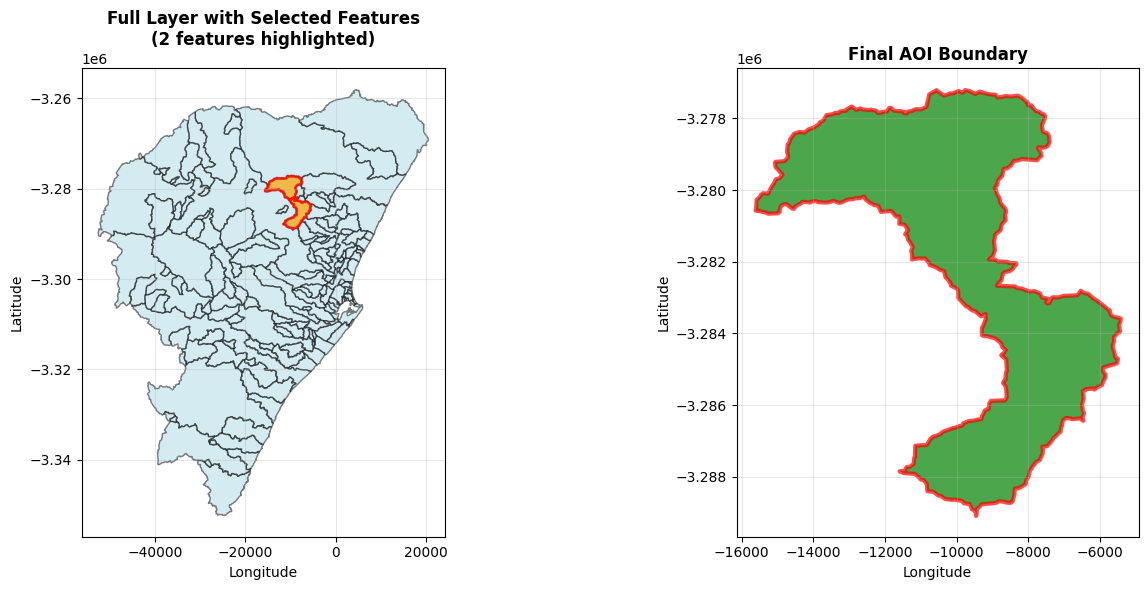

In [17]:
# ============================================================================
# STEP 8: VISUALIZE THE FILTERED AOI
# ============================================================================

print("\n" + "="*70)
print("VISUALIZING RESULTS")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original full layer
ax1 = axes[0]
gdf.plot(ax=ax1, alpha=0.5, edgecolor='k', color='lightblue')
gdf_aoi.plot(ax=ax1, alpha=0.7, edgecolor='r', linewidth=2, color='orange')
ax1.set_title(f'Full Layer with Selected Features\n({len(gdf_aoi)} features highlighted)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(alpha=0.3)

# AOI boundary only
ax2 = axes[1]
aoi_boundary.plot(ax=ax2, alpha=0.7, edgecolor='r', linewidth=3, color='green')
ax2.set_title('Final AOI Boundary', fontsize=12, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('aoi_boundary_selection.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved visualization: aoi_boundary_selection.png")
plt.show()

In [19]:
# ============================================================================
# STEP 9: SAVE AOI BOUNDARY AS NEW GEOPACKAGE
# ============================================================================

print("\n" + "="*70)
print("SAVING AOI BOUNDARY")
print("="*70)

# Define output path
output_gpkg = "aoi_boundary.gpkg"

# Save AOI boundary
aoi_boundary.to_file(output_gpkg, layer="aoi_boundary", driver="GPKG")
print(f"\n✓ Saved AOI boundary to: {output_gpkg}")
print(f"   Layer name: 'aoi_boundary'")

# Also save as backup in other formats
aoi_boundary.to_file("aoi_boundary.shp")
print("✓ Saved backup as shapefile: aoi_boundary.shp")


SAVING AOI BOUNDARY

✓ Saved AOI boundary to: aoi_boundary.gpkg
   Layer name: 'aoi_boundary'
✓ Saved backup as shapefile: aoi_boundary.shp


In [20]:
# ============================================================================
# STEP 10: VERIFY AND DISPLAY AOI INFORMATION
# ============================================================================

print("\n" + "="*70)
print("AOI BOUNDARY INFORMATION")
print("="*70)

print(f"\n✓ Coordinate Reference System: {aoi_boundary.crs}")
print(f"\n✓ Geometry Type: {aoi_boundary.geometry.type.values[0]}")
print(f"\n✓ Bounds (minx, miny, maxx, maxy):")
bounds = aoi_boundary.total_bounds
print(f"   {bounds}")

print(f"\n✓ Area: {aoi_boundary.geometry.area.sum():.2f} square units")

print(f"\n✓ Envelope (bounding box):")
envelope = aoi_boundary.geometry.envelope
print(envelope)

print(f"\n✓ Centroid:")
centroid = aoi_boundary.geometry.centroid
print(f"   Longitude: {centroid.x.values[0]:.4f}")
print(f"   Latitude: {centroid.y.values[0]:.4f}")



AOI BOUNDARY INFORMATION

✓ Coordinate Reference System: PROJCS["South Africa wg31",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",31],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

✓ Geometry Type: Polygon

✓ Bounds (minx, miny, maxx, maxy):
   [  -15623.3328 -3289077.2828    -5432.109  -3277195.8031]

✓ Area: 42287738.36 square units

✓ Envelope (bounding box):
0    POLYGON ((-15623.333 -3289077.283, -5432.109 -...
dtype: geometry

✓ Centroid:
   Longitude: -9801.8724
   Latitude: -3282156.9548


In [23]:
# ============================================================================
# STEP 11: PREPARE FOR NEXT WORKFLOW STEPS
# ============================================================================

print("\n" + "="*70)
print("READY FOR NEXT WORKFLOW")
print("="*70)

print(f"\n✓ AOI boundary successfully created and saved!")
print(f"\n✓ Use this for the next steps:")
print(f"   1. Load this AOI boundary in raster/vector operations")
print(f"   2. Clip raster layers to this boundary")
print(f"   3. Extract zonal statistics within AOI")
print(f"   4. Run MCDA analysis within AOI")

# Store for later use
aoi_gpkg = output_gpkg
aoi_layer = "aoi_boundary"

print(f"\n✓ AOI GeoPackage path: {aoi_gpkg}")
print(f"✓ AOI layer name: {aoi_layer}")

print("\n" + "="*70)


READY FOR NEXT WORKFLOW

✓ AOI boundary successfully created and saved!

✓ Use this for the next steps:
   1. Load this AOI boundary in raster/vector operations
   2. Clip raster layers to this boundary
   3. Extract zonal statistics within AOI
   4. Run MCDA analysis within AOI

✓ AOI GeoPackage path: aoi_boundary.gpkg
✓ AOI layer name: aoi_boundary

